In [15]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

In [2]:
# Load the engineered dataset
df_model = pd.read_csv("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/engineered_features.csv")
df_model.head()

,Tenure,Monthly Charges,Multiple Lines,Tenure Group,Charge Level,Churn
0,1,29.85,0,0,0,0
1,34,56.95,0,1,1,0
2,2,53.85,0,0,1,1
3,45,42.30,0,2,1,0
4,2,70.70,0,0,2,1


In [3]:
# Split into features (X) and target (y)
X = df_model[["Tenure Group", "Charge Level", "Multiple Lines"]]
y = df_model["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 3)
Target shape: (7032,)


In [4]:
# Split into training set and test set (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 5625
Test samples: 1407


In [5]:
# Train Model 1 — Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

In [6]:
# Evaluate Logistic Regression
print("=== Logistic Regression Results ===")
print()
print("Accuracy:", round(accuracy_score(y_test, lr_predictions) * 100, 2), "%")
print()
print("Classification Report:")
print(classification_report(y_test, lr_predictions, target_names=["No Churn", "Churn"]))

=== Logistic Regression Results ===

Accuracy: 77.33 %

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.79      0.95      0.86      1033
       Churn       0.67      0.29      0.41       374

    accuracy                           0.77      1407
   macro avg       0.73      0.62      0.63      1407
weighted avg       0.76      0.77      0.74      1407



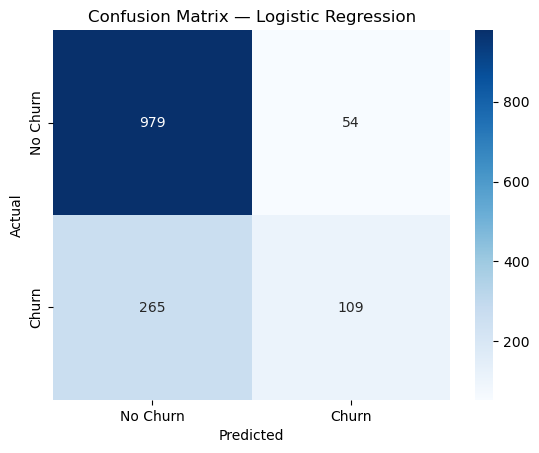

In [7]:
# Confusion Matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, lr_predictions)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
# Train Model 2 — Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

In [9]:
# Evaluate Decision Tree
print("=== Decision Tree Results ===")
print()
print("Accuracy:", round(accuracy_score(y_test, dt_predictions) * 100, 2), "%")
print()
print("Classification Report:")
print(classification_report(y_test, dt_predictions, target_names=["No Churn", "Churn"]))

=== Decision Tree Results ===

Accuracy: 77.33 %

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.79      0.95      0.86      1033
       Churn       0.67      0.29      0.41       374

    accuracy                           0.77      1407
   macro avg       0.73      0.62      0.63      1407
weighted avg       0.76      0.77      0.74      1407



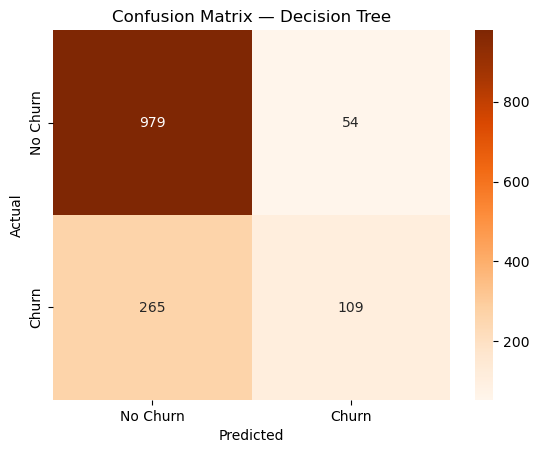

In [10]:
# Confusion Matrix — Decision Tree
cm_dt = confusion_matrix(y_test, dt_predictions)

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
# Side by side comparison
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy (%)": [
        round(accuracy_score(y_test, lr_predictions) * 100, 2),
        round(accuracy_score(y_test, dt_predictions) * 100, 2)
    ]
})

print(comparison)

                 Model  Accuracy (%)
0  Logistic Regression         77.33
1        Decision Tree         77.33


In [14]:
import subprocess
subprocess.run(["pip", "install", "imbalanced-learn"])

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


CompletedProcess(args=['pip', 'install', 'imbalanced-learn'], returncode=0)

In [16]:
# Apply SMOTE to balance the training data
# SMOTE creates synthetic churn examples so the model sees equal amounts of both classes
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_balanced).value_counts())
print()
print("No Churn:", pd.Series(y_train_balanced).value_counts()[0],
      "| Churn:", pd.Series(y_train_balanced).value_counts()[1])

Class distribution after SMOTE:
Churn
1    4130
0    4130
Name: count, dtype: int64

No Churn: 4130 | Churn: 4130


In [17]:
# Train Random Forest on the SMOTE-balanced training data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
rf_predictions = rf_model.predict(X_test)

print("=== Improved Model — Random Forest + SMOTE ===")
print("Accuracy:", round(accuracy_score(y_test, rf_predictions) * 100, 2), "%")
print()
print(classification_report(y_test, rf_predictions, target_names=["No Churn", "Churn"]))

=== Improved Model — Random Forest + SMOTE ===
Accuracy: 73.63 %

              precision    recall  f1-score   support

    No Churn       0.86      0.76      0.81      1033
       Churn       0.50      0.67      0.57       374

    accuracy                           0.74      1407
   macro avg       0.68      0.71      0.69      1407
weighted avg       0.77      0.74      0.75      1407



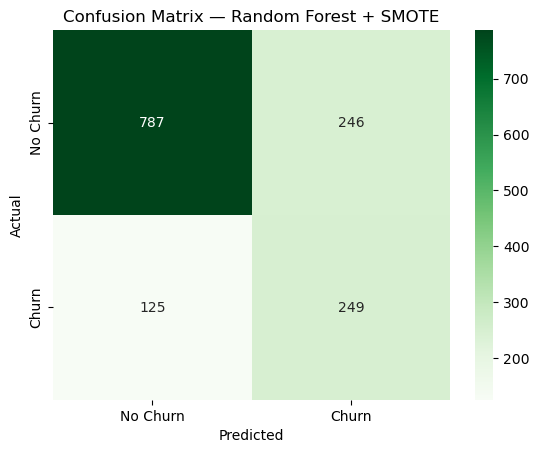

In [18]:
# Confusion Matrix — Random Forest + SMOTE
cm_rf = confusion_matrix(y_test, rf_predictions)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Random Forest + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Final comparison — Baseline vs Improved Model
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "Decision Tree (Baseline)", "Random Forest + SMOTE"],
    "Accuracy (%)": [
        round(accuracy_score(y_test, lr_predictions) * 100, 2),
        round(accuracy_score(y_test, dt_predictions) * 100, 2),
        round(accuracy_score(y_test, rf_predictions) * 100, 2)
    ]
})

print(comparison)

                            Model  Accuracy (%)
0  Logistic Regression (Baseline)         77.33
1        Decision Tree (Baseline)         77.33
2           Random Forest + SMOTE         73.63


In [20]:
# Fine-tune the Random Forest by adjusting key settings
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)

rf_tuned.fit(X_train_balanced, y_train_balanced)
rf_tuned_predictions = rf_tuned.predict(X_test)

print("=== Fine-Tuned Random Forest + SMOTE ===")
print("Accuracy:", round(accuracy_score(y_test, rf_tuned_predictions) * 100, 2), "%")
print()
print(classification_report(y_test, rf_tuned_predictions, target_names=["No Churn", "Churn"]))

=== Fine-Tuned Random Forest + SMOTE ===
Accuracy: 73.63 %

              precision    recall  f1-score   support

    No Churn       0.86      0.76      0.81      1033
       Churn       0.50      0.67      0.57       374

    accuracy                           0.74      1407
   macro avg       0.68      0.71      0.69      1407
weighted avg       0.77      0.74      0.75      1407



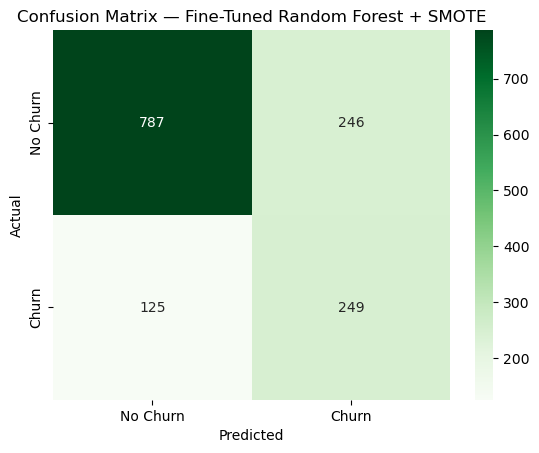

In [21]:
# Confusion Matrix — Fine-Tuned Random Forest
cm_tuned = confusion_matrix(y_test, rf_tuned_predictions)

sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Fine-Tuned Random Forest + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
# Full comparison — all three models side by side
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (Baseline)",
        "Decision Tree (Baseline)",
        "Random Forest + SMOTE",
        "Fine-Tuned Random Forest + SMOTE"
    ],
    "Accuracy (%)": [
        round(accuracy_score(y_test, lr_predictions) * 100, 2),
        round(accuracy_score(y_test, dt_predictions) * 100, 2),
        round(accuracy_score(y_test, rf_predictions) * 100, 2),
        round(accuracy_score(y_test, rf_tuned_predictions) * 100, 2)
    ]
})

print(comparison)

                              Model  Accuracy (%)
0    Logistic Regression (Baseline)         77.33
1          Decision Tree (Baseline)         77.33
2             Random Forest + SMOTE         73.63
3  Fine-Tuned Random Forest + SMOTE         73.63


In [23]:
# Save the final trained model so it can be reused without retraining
import pickle

with open("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/churn_model.pkl", "wb") as f:
    pickle.dump(rf_tuned, f)

print("Model saved as churn_model.pkl")

Model saved as churn_model.pkl


In [24]:
# Verify the model was saved correctly by loading it back and testing it
with open("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/churn_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Run a quick prediction to confirm it works
test_prediction = loaded_model.predict(X_test)
print("Model loaded and working correctly")
print("Accuracy on test set:", round(accuracy_score(y_test, test_prediction) * 100, 2), "%")

Model loaded and working correctly
Accuracy on test set: 73.63 %
